In [1]:
###############################################################################
# MVPA LIU DISTINCTIVENESS PIPELINE
#
# Validated parameters (see roi_validation notebook):
#   Localization: cat_vs_scramble (copes 10, 11, 3, 12)
#   Threshold: z > 1.96, top 10% suprathreshold voxels
#   Measurement: raw betas (copes 15-18) — no circularity
#   Sphere: 6mm around peak
#   Metric: Liu distinctiveness = mean Fisher-z correlation between
#           preferred category and non-preferred categories
#           (lower = more distinct/selective)
###############################################################################

In [2]:
###############################################################################
# CELL 1: Setup
###############################################################################
import os, sys, time
import numpy as np
import nibabel as nib
import pandas as pd
from pathlib import Path
from scipy.ndimage import label, center_of_mass
from scipy.stats import pearsonr, ttest_ind, ttest_rel, wilcoxon
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, is_patient,
                           get_sessions, get_sub_info, _load_csv)

BASE_DIR = Path(processed_dir)
HOME_OUTPUT = Path('/home/csimmon2/mvpa_liu_results')
HOME_OUTPUT.mkdir(parents=True, exist_ok=True)

df = _load_csv()

# ── Exclusions ──
SCANNER_SESSION_DROPS = {}
SCANNER_SUBJECT_DROPS = []
SUBJECTS_TO_SKIP = ['OTC108']
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}
AGE_MATCH_DROP = ['sub-025', 'sub-027', 'sub-045', 'sub-072']

# ── Contrasts ──
#LOC_COPES = {'face': 10, 'house': 11, 'object': 3, 'word': 12}  # cat > scramble # marlene does not like scramble
#LOC_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 12}  # word uses word > scramble to get more voxels, word wasn't strong enough otherwise
#LOC_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 4}  # differential contrasts

# === SELECT COPE MAP ===
COPE_SET = 'differential'  # Change to: 'differential', 'cat_vs_scramble', or 'hybrid'

COPE_MAPS = {
    'differential':    {'face': 1, 'house': 2, 'object': 3, 'word': 4},
    'cat_vs_scramble': {'face': 10, 'house': 11, 'object': 3, 'word': 12},
    'hybrid':          {'face': 1, 'house': 2, 'object': 3, 'word': 12},
}

LOC_COPES = COPE_MAPS[COPE_SET]
print(f"Using COPE set: {COPE_SET} → {LOC_COPES}")

RSA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}  # raw betas

CATEGORIES = ['face', 'house', 'object', 'word']
BILATERAL_CATEGORIES = ['object', 'house']
PREFERRED_HEMI = {'Face': 'r', 'Word': 'l', 'House': 'both', 'Object': 'both'}

print(f'Setup complete. Output: {HOME_OUTPUT}')

Using COPE set: differential → {'face': 1, 'house': 2, 'object': 3, 'word': 4}
Setup complete. Output: /home/csimmon2/mvpa_liu_results


In [3]:

###############################################################################
# CELL 2: Load Subjects
###############################################################################

def load_subjects(patient_only=None):
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        subject_id = f'sub-{sub_clean}'
        if subject_id in SCANNER_SUBJECT_DROPS:
            continue
        sessions = get_sessions(sub_clean)
        if not sessions:
            continue
        if subject_id in SCANNER_SESSION_DROPS:
            sessions = [s for s in sessions
                       if f'{s:02d}' not in SCANNER_SESSION_DROPS[subject_id]]
        if not sessions:
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        if patient_only is True and not pt:
            continue
        if patient_only is False and pt:
            continue
        if not (BASE_DIR / subject_id).exists():
            continue
        intact = info.get('intact_hemi', '')
        hemi = ('l' if intact == 'left' else 'r') if pt else 'r'
        subjects[subject_id] = {
            'code': f"{info.get('group','')}{sub_clean}",
            'sessions': [f'{s:02d}' for s in sessions],
            'hemi': hemi,
            'group': info.get('group', 'unknown'),
            'patient_status': 'patient' if pt else 'control',
            'intact_hemi': intact
        }
    return subjects

ALL_PATIENTS = load_subjects(patient_only=True)
ALL_CONTROLS = load_subjects(patient_only=False)
SUBS = {**ALL_PATIENTS, **ALL_CONTROLS}

# Age lookup
AGE_MAP = {}
for sid, info in SUBS.items():
    sub_clean = sid.replace('sub-', '')
    sub_rows = df[df['sub_clean'] == sub_clean]
    if len(sub_rows) > 0:
        AGE_MAP[info['code']] = sub_rows.iloc[0]['age']

print(f'Patients: {len(ALL_PATIENTS)}, Controls: {len(ALL_CONTROLS)}, Total: {len(SUBS)}')

Patients: 26, Controls: 24, Total: 50


In [4]:

###############################################################################
# CELL 3: NIfTI Cache + ROI Extraction
###############################################################################

_CACHE = {}

def _load(fp):
    k = str(fp)
    if k not in _CACHE:
        _CACHE[k] = nib.load(k)
    return _CACHE[k]

def clear_cache():
    global _CACHE
    n = len(_CACHE)
    _CACHE = {}
    print(f'Cleared {n} cached files')


def extract_roi(subject_id, session, category, hemi,
                threshold_z=1.96, top_pct=0.10, min_voxels=50):
    """
    Extract functional ROI using cat_vs_scramble localizer.
    z > 1.96 within search mask, top 10% of suprathreshold, largest cluster.
    Returns peak, centroid, roi_mask, or None.
    """
    info = SUBS[subject_id]
    first_ses = info['sessions'][0]
    cope_num = LOC_COPES[category]

    # Brain mask
    bm_file = BASE_DIR / subject_id / f'ses-{first_ses}' / 'anat' / 'T1w_brain_mask.nii.gz'
    bm = _load(bm_file).get_fdata() > 0 if bm_file.exists() else None

    # Search mask
    mf = None
    for sd in ['ROIs', os.path.join('derivatives', 'rois')]:
        p = BASE_DIR / subject_id / f'ses-{first_ses}' / sd / f'{hemi}_{category}_searchmask.nii.gz'
        if p.exists():
            mf = p
            break
    if mf is None:
        return None

    mi = _load(mf)
    mask = mi.get_fdata() > 0
    affine = mi.affine

    # Zstat
    feat = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'
    zn = 'zstat1.nii.gz' if session == first_ses else f'zstat1_ses{first_ses}.nii.gz'
    zf = feat / f'cope{cope_num}.feat' / 'stats' / zn
    if not zf.exists():
        return None

    z = _load(zf).get_fdata().copy()
    if bm is not None:
        z[~bm] = 0

    supra = (z > threshold_z) & mask
    ns = supra.sum()
    if ns < min_voxels:
        return None

    top_n = max(min_voxels, int(ns * top_pct))
    top_n = min(top_n, ns)
    vals = z[supra]
    thresh = np.sort(vals)[-top_n]
    top = (z >= thresh) & supra

    labeled, nc = label(top)
    if nc == 0:
        return None

    sizes = [(labeled == i).sum() for i in range(1, nc + 1)]
    li = np.argmax(sizes) + 1
    roi = (labeled == li)
    peak_idx = np.unravel_index(np.argmax(z * roi), z.shape)

    return {
        'n_voxels': sizes[li - 1],
        'peak_z': z[peak_idx],
        'peak_coord': nib.affines.apply_affine(affine, np.array(peak_idx)),
        'centroid': nib.affines.apply_affine(affine, np.array(center_of_mass(roi))),
        'roi_mask': roi,
        'affine': affine,
        'brain_shape': z.shape,
    }


print('ROI extraction defined.')

ROI extraction defined.


In [5]:

###############################################################################
# CELL 4: Sphere Creation + Beta Extraction + Liu Distinctiveness
###############################################################################

def create_sphere(peak_coord, affine, brain_shape, radius=6):
    """6mm sphere around peak in world coordinates."""
    grid = np.array(np.meshgrid(
        np.arange(brain_shape[0]),
        np.arange(brain_shape[1]),
        np.arange(brain_shape[2]),
        indexing='ij'
    )).reshape(3, -1).T
    world = nib.affines.apply_affine(affine, grid)
    dists = np.linalg.norm(world - peak_coord, axis=1)
    mask = np.zeros(brain_shape, dtype=bool)
    within = grid[dists <= radius]
    for c in within:
        mask[c[0], c[1], c[2]] = True
    return mask


def extract_sphere_betas(subject_id, session, sphere_mask):
    """Extract raw beta patterns (copes 15-18) from sphere. Returns 4×N matrix or None."""
    info = SUBS[subject_id]
    first_ses = info['sessions'][0]
    feat = BASE_DIR / subject_id / f'ses-{session}' / 'derivatives' / 'fsl' / 'loc' / 'HighLevel.gfeat'
    cn = 'cope1.nii.gz' if session == first_ses else f'cope1_ses{first_ses}.nii.gz'

    patterns = []
    valid_cats = []
    for cat in CATEGORIES:
        cf = feat / f'cope{RSA_COPES[cat]}.feat' / 'stats' / cn
        if not cf.exists():
            continue
        betas = _load(cf).get_fdata()[sphere_mask]
        betas = betas[np.isfinite(betas)]
        if len(betas) > 0:
            patterns.append(betas)
            valid_cats.append(cat)

    if len(patterns) < 4:
        return None, None

    min_v = min(len(b) for b in patterns)
    patterns = [b[:min_v] for b in patterns]
    return np.column_stack(patterns), valid_cats


def compute_liu_distinctiveness(beta_matrix, valid_cats, roi_category):
    """
    Liu distinctiveness: mean Fisher-z transformed correlation between
    preferred category pattern and each non-preferred category pattern.
    Lower = more distinct/selective.
    """
    if valid_cats is None or len(valid_cats) < 4:
        return None
    if roi_category not in valid_cats:
        return None

    corr = np.corrcoef(beta_matrix.T)
    fisher = np.arctanh(np.clip(corr, -0.999, 0.999))

    pref_idx = valid_cats.index(roi_category)
    nonpref = [i for i in range(len(valid_cats)) if i != pref_idx]
    mean_corr = np.mean(fisher[pref_idx, nonpref])

    return mean_corr


print('Sphere + beta + distinctiveness functions defined.')

Sphere + beta + distinctiveness functions defined.


In [6]:

###############################################################################
# CELL 5: Run Full Pipeline — All Subjects × Sessions × Categories × Hemis
###############################################################################

def run_pipeline():
    """Extract ROIs, build spheres, compute Liu distinctiveness for everything."""
    print('RUNNING FULL PIPELINE')
    print('=' * 70)
    t0 = time.time()

    rows = []

    for sub_idx, (sid, info) in enumerate(sorted(SUBS.items())):
        code = info['code']
        first_ses = info['sessions'][0]
        print(f'  [{sub_idx+1}/{len(SUBS)}] {code} ({time.time()-t0:.0f}s)', end='\r')

        for session in info['sessions']:
            if sid in PRE_SURGERY_SESSIONS and session in PRE_SURGERY_SESSIONS[sid]:
                continue

            for hemi in ['l', 'r']:
                for category in CATEGORIES:
                    # Step 1: Extract ROI
                    roi = extract_roi(sid, session, category, hemi)
                    if roi is None:
                        continue

                    # Step 2: Build sphere
                    sphere = create_sphere(roi['peak_coord'], roi['affine'],
                                          roi['brain_shape'], radius=6)

                    # Step 3: Extract betas
                    betas, vcats = extract_sphere_betas(sid, session, sphere)
                    if betas is None:
                        continue

                    # Step 4: Compute distinctiveness
                    liu = compute_liu_distinctiveness(betas, vcats, category)
                    if liu is None:
                        continue

                    # Hemisphere label
                    if info['patient_status'] == 'patient':
                        intact = info['intact_hemi']
                        hl = ('Intact' if (hemi == 'l' and intact == 'left') or
                              (hemi == 'r' and intact == 'right') else 'Lesioned')
                    else:
                        hl = 'Left' if hemi == 'l' else 'Right'

                    rows.append({
                        'subject': code, 'subject_id': sid,
                        'group': info['group'] if info['patient_status'] == 'patient' else 'control',
                        'status': info['patient_status'],
                        'session': session, 'hemi': hemi,
                        'hemi_label': hl, 'category': category,
                        'liu_distinctiveness': liu,
                        'peak_z': roi['peak_z'],
                        'n_voxels': roi['n_voxels'],
                        'sphere_voxels': sphere.sum(),
                    })

    print(f'\n  Done: {time.time()-t0:.0f}s')
    result_df = pd.DataFrame(rows)
    print(f'  {len(result_df)} measurements, {result_df["subject"].nunique()} subjects')
    return result_df


results = run_pipeline()
results.to_csv(HOME_OUTPUT / 'liu_distinctiveness_all.csv', index=False)
clear_cache()

RUNNING FULL PIPELINE
  [50/50] control097 (546s)
  Done: 554s
  547 measurements, 49 subjects
Cleared 1038 cached files


In [7]:
###############################################################################
# CELL 6: Cross-Sectional Analysis — First Post-Surgery Session
###############################################################################

def cross_sectional(results):
    """Compare baseline distinctiveness: OTC vs Controls."""
    print('\nCROSS-SECTIONAL: FIRST POST-SURGERY SESSION')
    print('=' * 70)

    # First session per subject
    first_rows = []
    for sid, info in SUBS.items():
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if not post:
            continue
        first_rows.append({'subject_id': sid, 'target_session': post[0]})
    first_df = pd.DataFrame(first_rows)

    cross = results.merge(first_df, left_on=['subject_id', 'session'],
                          right_on=['subject_id', 'target_session'])

    # Controls: preferred hemisphere, average bilateral
    ctrl = cross[cross['status'] == 'control'].copy()
    ctrl_pref = ctrl[ctrl.apply(
        lambda r: PREFERRED_HEMI[r['category'].title()] in ('both', r['hemi']), axis=1)]
    ctrl_avg = ctrl_pref.groupby(['subject', 'category']).agg(
        {'liu_distinctiveness': 'mean'}).reset_index()
    ctrl_avg['group'] = 'control'
    ctrl_avg['age'] = ctrl_avg['subject'].map(AGE_MAP)

    # Patients: intact hemisphere
    otc = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'Intact')].copy()
    otc['age'] = otc['subject'].map(AGE_MAP)

    nonotc = cross[(cross['group'] == 'nonOTC') & (cross['hemi_label'] == 'Intact')].copy()
    nonotc['age'] = nonotc['subject'].map(AGE_MAP)

    # Print means
    print(f"\n{'Group':<12} {'Face':<10} {'House':<10} {'Object':<10} {'Word'}")
    print('-' * 50)
    for name, data in [('OTC', otc), ('nonOTC', nonotc), ('Controls', ctrl_avg)]:
        vals = {cat: data[data['category'] == cat]['liu_distinctiveness'].mean()
                for cat in CATEGORIES}
        print(f"{name:<12} {vals['face']:<10.3f} {vals['house']:<10.3f} "
              f"{vals['object']:<10.3f} {vals['word']:.3f}")

    # OLS with age
    print(f"\nOLS: liu ~ C(group, Treatment('control')) + age")
    print('-' * 60)
    for cat in CATEGORIES:
        model_data = pd.concat([
            ctrl_avg[ctrl_avg['category'] == cat][['subject', 'group', 'age', 'liu_distinctiveness']],
            otc[otc['category'] == cat][['subject', 'group', 'age', 'liu_distinctiveness']],
        ], ignore_index=True).dropna()

        if len(model_data[model_data['group'] == 'OTC']) < 2:
            continue
        try:
            m = smf.ols('liu_distinctiveness ~ C(group, Treatment("control")) + age',
                       data=model_data).fit()
            gk = [k for k in m.params.index if 'OTC' in k][0]
            print(f'  {cat}: coef={m.params[gk]:.3f} p={m.pvalues[gk]:.4f} '
                  f'| age p={m.pvalues["age"]:.4f} | R2={m.rsquared:.3f}')
        except Exception as e:
            print(f'  {cat}: failed ({e})')

    return cross, ctrl_avg, otc, nonotc


cross_df, ctrl_cross, otc_cross, nonotc_cross = cross_sectional(results)


CROSS-SECTIONAL: FIRST POST-SURGERY SESSION

Group        Face       House      Object     Word
--------------------------------------------------
OTC          0.874      0.507      1.159      0.883
nonOTC       0.659      0.334      1.224      0.791
Controls     0.728      0.393      1.105      0.465

OLS: liu ~ C(group, Treatment('control')) + age
------------------------------------------------------------
  face: coef=0.148 p=0.2576 | age p=0.4650 | R2=0.050
  house: coef=0.115 p=0.6102 | age p=0.9631 | R2=0.007
  object: coef=0.054 p=0.6683 | age p=0.5858 | R2=0.013
  word: coef=0.417 p=0.0133 | age p=0.8118 | R2=0.173


In [8]:

###############################################################################
# CELL 7: Longitudinal Analysis — Change Over Time
###############################################################################

def longitudinal(results):
    """
    For subjects with 2+ post-surgery sessions:
    compute signed change in distinctiveness (final - baseline).
    OTC vs Controls.
    """
    print('\nLONGITUDINAL: CHANGE IN DISTINCTIVENESS')
    print('=' * 70)

    rows = []
    for sid, info in SUBS.items():
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if len(post) < 2:
            continue

        code = info['code']
        s1, s2 = post[0], post[-1]

        for category in CATEGORIES:
            # For controls: preferred hemisphere
            if info['patient_status'] == 'control':
                pref = PREFERRED_HEMI[category.title()]
                hemis_to_use = ['l', 'r'] if pref == 'both' else [pref[0]]
            else:
                # Patients: intact hemisphere
                hemis_to_use = ['l' if info['intact_hemi'] == 'left' else 'r']

            vals = []
            for h in hemis_to_use:
                d1 = results[(results['subject_id'] == sid) &
                             (results['session'] == s1) &
                             (results['hemi'] == h) &
                             (results['category'] == category)]
                d2 = results[(results['subject_id'] == sid) &
                             (results['session'] == s2) &
                             (results['hemi'] == h) &
                             (results['category'] == category)]
                if len(d1) > 0 and len(d2) > 0:
                    vals.append(d2.iloc[0]['liu_distinctiveness'] -
                               d1.iloc[0]['liu_distinctiveness'])

            if not vals:
                continue

            rows.append({
                'subject': code, 'subject_id': sid,
                'group': info['group'] if info['patient_status'] == 'patient' else 'control',
                'status': info['patient_status'],
                'category': category,
                'cat_type': 'bilateral' if category in BILATERAL_CATEGORIES else 'unilateral',
                'signed_change': np.mean(vals),
                'abs_change': abs(np.mean(vals)),
                'n_sessions': len(post),
                'age': AGE_MAP.get(code, np.nan),
            })

    long_df = pd.DataFrame(rows)

    # Exclude age-match drops
    drop_codes = set()
    for s in AGE_MATCH_DROP:
        num = s.replace('sub-', '')
        drop_codes.update([f'OTC{num}', f'nonOTC{num}', f'control{num}'])
    long_df = long_df[~long_df['subject'].isin(drop_codes)]

    # Filter to OTC + controls
    otc_long = long_df[long_df['group'] == 'OTC']
    ctrl_long = long_df[long_df['status'] == 'control']

    print(f'OTC: {otc_long["subject"].nunique()} subjects')
    print(f'Controls: {ctrl_long["subject"].nunique()} subjects')

    # Signed change
    print(f"\nSIGNED CHANGE (negative = more selective over time):")
    print(f"{'Group':<12} {'Face':<10} {'House':<10} {'Object':<10} {'Word'}")
    print('-' * 50)
    for name, data in [('OTC', otc_long), ('Controls', ctrl_long)]:
        vals = {cat: data[data['category'] == cat]['signed_change'].mean()
                for cat in CATEGORIES}
        print(f"{name:<12} {vals.get('face',0):<+10.3f} {vals.get('house',0):<+10.3f} "
              f"{vals.get('object',0):<+10.3f} {vals.get('word',0):+.3f}")

    # Bilateral vs unilateral
    print(f"\n{'Group':<12} {'Bilateral':<12} {'Unilateral'}")
    print('-' * 35)
    for name, data in [('OTC', otc_long), ('Controls', ctrl_long)]:
        bil = data[data['cat_type'] == 'bilateral']['signed_change'].mean()
        uni = data[data['cat_type'] == 'unilateral']['signed_change'].mean()
        print(f"{name:<12} {bil:<+12.3f} {uni:+.3f}")

    # OLS with age
    print(f"\nOLS: signed_change ~ C(group) + age")
    print('-' * 60)
    combined = pd.concat([otc_long, ctrl_long], ignore_index=True)
    for cat in CATEGORIES:
        cd = combined[combined['category'] == cat].dropna(subset=['age'])
        if len(cd[cd['group'] == 'OTC']) < 2:
            continue
        try:
            m = smf.ols('signed_change ~ C(group, Treatment("control")) + age',
                       data=cd).fit()
            gk = [k for k in m.params.index if 'OTC' in k][0]
            print(f'  {cat}: coef={m.params[gk]:.3f} p={m.pvalues[gk]:.4f} '
                  f'| age p={m.pvalues["age"]:.4f}')
        except Exception as e:
            print(f'  {cat}: failed ({e})')

    return long_df, otc_long, ctrl_long


long_df, otc_long, ctrl_long = longitudinal(results)
long_df.to_csv(HOME_OUTPUT / 'longitudinal_change.csv', index=False)


LONGITUDINAL: CHANGE IN DISTINCTIVENESS
OTC: 6 subjects
Controls: 7 subjects

SIGNED CHANGE (negative = more selective over time):
Group        Face       House      Object     Word
--------------------------------------------------
OTC          -0.362     -0.369     -0.000     -0.568
Controls     -0.071     -0.203     +0.018     +0.123

Group        Bilateral    Unilateral
-----------------------------------
OTC          -0.184       -0.456
Controls     -0.093       +0.026

OLS: signed_change ~ C(group) + age
------------------------------------------------------------
  face: coef=-0.242 p=0.3304 | age p=0.2941
  house: coef=-0.271 p=0.4292 | age p=0.1135
  object: coef=-0.026 p=0.9352 | age p=0.8997
  word: coef=-0.659 p=0.0196 | age p=0.0284


In [9]:
###############################################################################
# CELL 7b: Longitudinal — Absolute Change + Bilateral vs Unilateral
###############################################################################

def absolute_change_analysis(long_df):
    """Replicate old notebook's key finding: bilateral vs unilateral absolute change."""
    print('\nABSOLUTE CHANGE: BILATERAL vs UNILATERAL')
    print('=' * 70)

    otc_long = long_df[long_df['group'] == 'OTC']
    nonotc_long = long_df[long_df['group'] == 'nonOTC']
    ctrl_long = long_df[long_df['status'] == 'control']

    # Per-category absolute change
    print(f"\nABSOLUTE CHANGE BY CATEGORY:")
    print(f"{'Group':<12} {'Face':<10} {'House':<10} {'Object':<10} {'Word'}")
    print('-' * 50)
    for name, data in [('OTC', otc_long), ('nonOTC', nonotc_long), ('Controls', ctrl_long)]:
        vals = {cat: data[data['category'] == cat]['abs_change'].mean()
                for cat in CATEGORIES}
        print(f"{name:<12} {vals.get('face',0):<10.3f} {vals.get('house',0):<10.3f} "
              f"{vals.get('object',0):<10.3f} {vals.get('word',0):.3f}")

    # Bilateral vs unilateral
    print(f"\nBILATERAL vs UNILATERAL (absolute change):")
    print(f"{'Group':<12} {'Bilateral':<12} {'Unilateral':<12} {'Difference':<12} {'Bil>Uni?'}")
    print('-' * 60)
    for name, data in [('OTC', otc_long), ('nonOTC', nonotc_long), ('Controls', ctrl_long)]:
        bil = data[data['cat_type'] == 'bilateral']['abs_change'].mean()
        uni = data[data['cat_type'] == 'unilateral']['abs_change'].mean()
        diff = bil - uni
        status = '✓' if bil > uni else '✗'
        print(f"{name:<12} {bil:<12.3f} {uni:<12.3f} {diff:<12.3f} {status}")

    # Signed change for comparison
    print(f"\nSIGNED CHANGE (for comparison):")
    print(f"{'Group':<12} {'Bilateral':<12} {'Unilateral':<12} {'Difference'}")
    print('-' * 50)
    for name, data in [('OTC', otc_long), ('nonOTC', nonotc_long), ('Controls', ctrl_long)]:
        bil = data[data['cat_type'] == 'bilateral']['signed_change'].mean()
        uni = data[data['cat_type'] == 'unilateral']['signed_change'].mean()
        diff = bil - uni
        print(f"{name:<12} {bil:<+12.3f} {uni:<+12.3f} {diff:+.3f}")


absolute_change_analysis(long_df)


ABSOLUTE CHANGE: BILATERAL vs UNILATERAL

ABSOLUTE CHANGE BY CATEGORY:
Group        Face       House      Object     Word
--------------------------------------------------
OTC          0.507      0.509      0.451      0.698
nonOTC       0.005      0.219      0.034      nan
Controls     0.254      0.494      0.339      0.263

BILATERAL vs UNILATERAL (absolute change):
Group        Bilateral    Unilateral   Difference   Bil>Uni?
------------------------------------------------------------
OTC          0.480        0.594        -0.114       ✗
nonOTC       0.126        0.005        0.121        ✓
Controls     0.417        0.259        0.158        ✓

SIGNED CHANGE (for comparison):
Group        Bilateral    Unilateral   Difference
--------------------------------------------------
OTC          -0.184       -0.456       +0.271
nonOTC       +0.092       +0.005       +0.087
Controls     -0.093       +0.026       -0.118


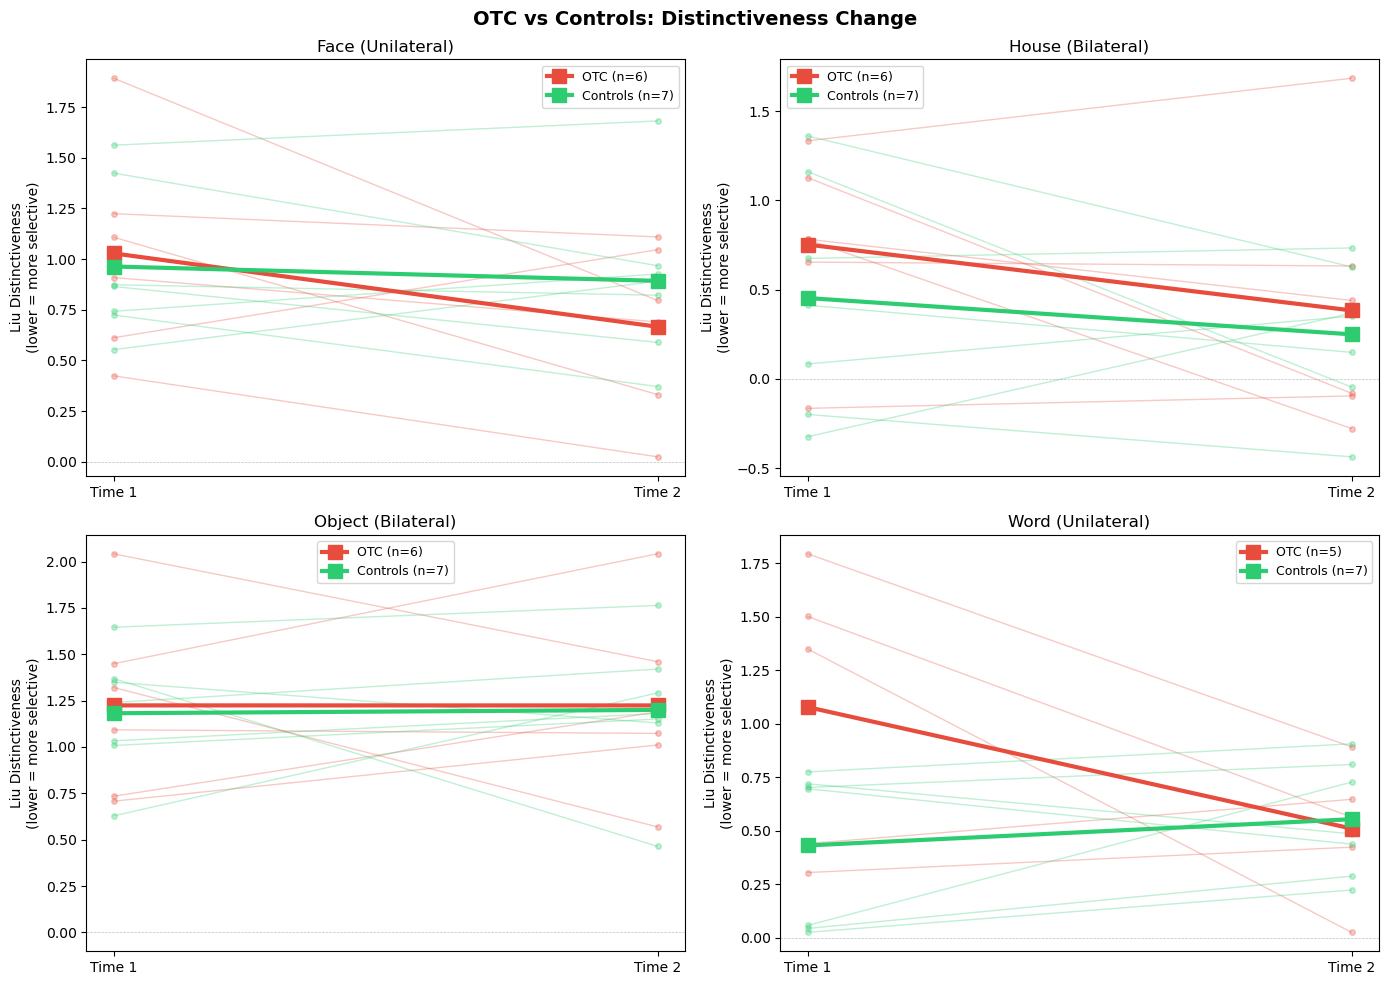

In [10]:
###############################################################################
# CELL 8: Longitudinal Trajectory Plot
###############################################################################

def plot_trajectories(results):
    """Individual trajectories T1→T2 for OTC vs Controls."""
    colors = {'OTC': '#e74c3c', 'Controls': '#2ecc71'}
    drop_codes = set()
    for s in AGE_MATCH_DROP:
        num = s.replace('sub-', '')
        drop_codes.update([f'OTC{num}', f'nonOTC{num}', f'control{num}'])

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for cat_idx, category in enumerate(CATEGORIES):
        ax = axes[cat_idx // 2][cat_idx % 2]
        cat_type = 'Bilateral' if category in BILATERAL_CATEGORIES else 'Unilateral'

        for gname, gfilter in [('OTC', 'OTC'), ('Controls', 'control')]:
            t1_vals, t2_vals = [], []

            for sid, info in SUBS.items():
                if info['code'] in drop_codes or info['code'] in SUBJECTS_TO_SKIP:
                    continue
                if gfilter == 'OTC' and info['group'] != 'OTC':
                    continue
                if gfilter == 'control' and info['patient_status'] != 'control':
                    continue

                post = [s for s in info['sessions']
                       if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
                if len(post) < 2:
                    continue

                # Get preferred/intact hemisphere
                if info['patient_status'] == 'control':
                    pref = PREFERRED_HEMI[category.title()]
                    hemis = ['l', 'r'] if pref == 'both' else [pref[0]]
                else:
                    hemis = ['l' if info['intact_hemi'] == 'left' else 'r']

                v1s, v2s = [], []
                for h in hemis:
                    d1 = results[(results['subject_id'] == sid) &
                                 (results['session'] == post[0]) &
                                 (results['hemi'] == h) &
                                 (results['category'] == category)]
                    d2 = results[(results['subject_id'] == sid) &
                                 (results['session'] == post[-1]) &
                                 (results['hemi'] == h) &
                                 (results['category'] == category)]
                    if len(d1) > 0 and len(d2) > 0:
                        v1s.append(d1.iloc[0]['liu_distinctiveness'])
                        v2s.append(d2.iloc[0]['liu_distinctiveness'])

                if v1s:
                    y1, y2 = np.mean(v1s), np.mean(v2s)
                    ax.plot([0, 1], [y1, y2], '-o', color=colors[gname],
                           alpha=0.3, markersize=4, linewidth=1)
                    t1_vals.append(y1)
                    t2_vals.append(y2)

            if t1_vals:
                ax.plot([0, 1], [np.mean(t1_vals), np.mean(t2_vals)], '-s',
                       color=colors[gname], linewidth=3, markersize=10,
                       label=f'{gname} (n={len(t1_vals)})', zorder=10)

        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_title(f'{category.title()} ({cat_type})')
        ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Time 1', 'Time 2'])
        ax.legend(fontsize=9)

    plt.suptitle('OTC vs Controls: Distinctiveness Change',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(str(HOME_OUTPUT / 'trajectories.png'), dpi=300, bbox_inches='tight')
    plt.show()


plot_trajectories(results)

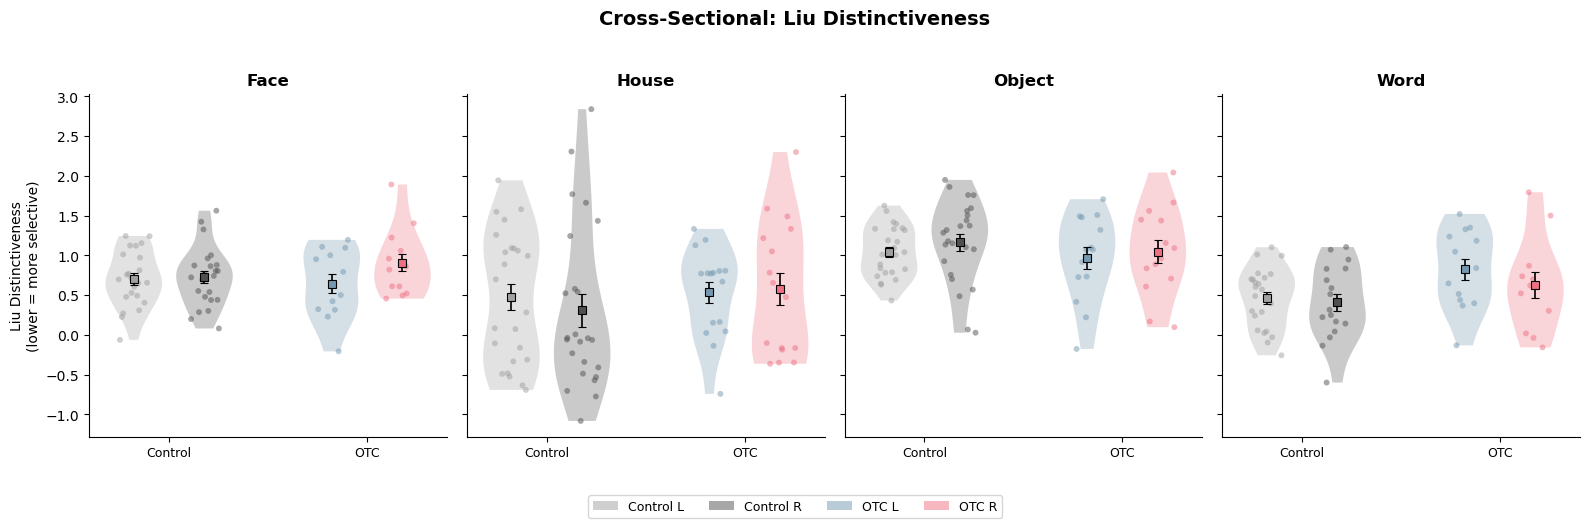

In [11]:
###############################################################################
# CELL 9: Cross-Sectional Violin Plot
###############################################################################

def plot_cross_sectional(results):
    """Violin plot: OTC vs Controls, first post-surgery session."""
    # Get first session data
    first_rows = []
    for sid, info in SUBS.items():
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if post:
            first_rows.append({'subject_id': sid, 'target_session': post[0]})
    first_df = pd.DataFrame(first_rows)
    cross = results.merge(first_df, left_on=['subject_id', 'session'],
                          right_on=['subject_id', 'target_session'])

    # Exclude nonOTC for main plot
    cross = cross[cross['group'] != 'nonOTC']

    slot_colors = {
        ('control', 'Left'): '#a0a0a0', ('control', 'Right'): '#505050',
        ('OTC', 'Left'): '#7398af', ('OTC', 'Right'): '#ee7183',
    }

    fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
    rng = np.random.default_rng(2)

    plot_slots = [
        ('control', 'Left', 0.0), ('control', 'Right', 0.5),
        ('OTC', 'Left', 1.4), ('OTC', 'Right', 1.9),
    ]

    for col_idx, cat in enumerate(CATEGORIES):
        ax = axes[col_idx]
        cat_data = cross[cross['category'] == cat]
        vd, vp, vc = [], [], []

        for grp, hl, pos in plot_slots:
            color = slot_colors[(grp, hl)]
            if grp == 'control':
                gd = cat_data[(cat_data['status'] == 'control') &
                              (cat_data['hemi_label'] == hl)]['liu_distinctiveness'].values
            else:
                gd = cat_data[(cat_data['group'] == grp) &
                              (cat_data['hemi'] == ('l' if hl == 'Left' else 'r'))]['liu_distinctiveness'].values

            if len(gd) < 2:
                continue

            vd.append(gd); vp.append(pos); vc.append(color)
            jitter = rng.uniform(-0.12, 0.12, len(gd))
            ax.scatter(np.full(len(gd), pos) + jitter, gd,
                      color=color, alpha=0.5, s=18, zorder=3, edgecolors='none')
            ax.errorbar(pos, np.mean(gd), yerr=np.std(gd)/np.sqrt(len(gd)),
                       color='black', marker='s', markersize=6,
                       markerfacecolor=color, markeredgecolor='black',
                       markeredgewidth=0.8, capsize=3, linewidth=1.2, zorder=5)

        if vd:
            vplot = ax.violinplot(vd, positions=vp, showmeans=False,
                                  showmedians=False, showextrema=False, widths=0.4)
            for i, body in enumerate(vplot['bodies']):
                body.set_facecolor(vc[i]); body.set_alpha(0.3); body.set_edgecolor('none')

        ax.set_xticks([0.25, 1.65])
        ax.set_xticklabels(['Control', 'OTC'], fontsize=9)
        ax.set_title(cat.title(), fontsize=12, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel('Liu Distinctiveness\n(lower = more selective)')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    legend_elements = [
        Patch(facecolor='#a0a0a0', alpha=0.5, label='Control L'),
        Patch(facecolor='#505050', alpha=0.5, label='Control R'),
        Patch(facecolor='#7398af', alpha=0.5, label='OTC L'),
        Patch(facecolor='#ee7183', alpha=0.5, label='OTC R'),
    ]
    fig.legend(handles=legend_elements, loc='lower center',
               ncol=4, fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.05))

    plt.suptitle('Cross-Sectional: Liu Distinctiveness', fontsize=14, fontweight='bold')
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(str(HOME_OUTPUT / 'cross_sectional.png'), dpi=300, bbox_inches='tight')
    plt.show()


plot_cross_sectional(results)

In [12]:
###############################################################################
# CELL 10: Summary Counts + Output
###############################################################################

def print_summary(results, long_df):
    print('\n' + '=' * 70)
    print('PIPELINE SUMMARY')
    print('=' * 70)

    # Cross-sectional counts
    print(f'\nCross-sectional (all post-surgery sessions):')
    for grp in ['control', 'OTC', 'nonOTC']:
        gd = results[results['group'] == grp]
        print(f'  {grp}: {gd["subject"].nunique()} subjects, {len(gd)} measurements')

    # Longitudinal counts
    print(f'\nLongitudinal (2+ sessions, age-matched):')
    for grp in ['control', 'OTC']:
        gd = long_df[long_df['group'] == grp]
        print(f'  {grp}: {gd["subject"].nunique()} subjects')

    print(f'\nParameters:')
    print(f'  Localizer: cat_vs_scramble (copes {list(LOC_COPES.values())})')
    print(f'  Threshold: z > 1.96, top 10%')
    print(f'  RSA betas: copes {list(RSA_COPES.values())}')
    print(f'  Sphere: 6mm')
    print(f'  Metric: Liu distinctiveness (Fisher-z, lower = more selective)')

    print(f'\nFiles:')
    for f in sorted(HOME_OUTPUT.glob('*')):
        print(f'  {f.name}')


print_summary(results, long_df)


PIPELINE SUMMARY

Cross-sectional (all post-surgery sessions):
  control: 24 subjects, 257 measurements
  OTC: 16 subjects, 187 measurements
  nonOTC: 9 subjects, 103 measurements

Longitudinal (2+ sessions, age-matched):
  control: 7 subjects
  OTC: 6 subjects

Parameters:
  Localizer: cat_vs_scramble (copes [1, 2, 3, 4])
  Threshold: z > 1.96, top 10%
  RSA betas: copes [15, 16, 17, 18]
  Sphere: 6mm
  Metric: Liu distinctiveness (Fisher-z, lower = more selective)

Files:
  cross_sectional.png
  liu_distinctiveness_all.csv
  longitudinal_change.csv
  trajectories.png


In [13]:
###############################################################################
# Deep dive: Per-category distinctiveness by resection side
###############################################################################

def deep_dive(results):
    """Category-level analysis split by hemisphere of resection."""
    
    # First post-surgery session only
    first_rows = []
    for sid, info in SUBS.items():
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if post:
            first_rows.append({'subject_id': sid, 'target_session': post[0]})
    first_df = pd.DataFrame(first_rows)
    cross = results.merge(first_df, left_on=['subject_id', 'session'],
                          right_on=['subject_id', 'target_session'])

    # OTC only, intact hemisphere
    otc = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'Intact')].copy()
    
    # Split by surgery side
    otc_info = {sid: SUBS[sid] for sid in otc['subject_id'].unique() if sid in SUBS}
    otc['surgery_side'] = otc['subject_id'].map(
        lambda s: 'left' if SUBS[s]['intact_hemi'] == 'right' else 'right' 
        if s in SUBS else None)
    
    # Controls — preferred hemisphere, average bilateral
    ctrl = cross[cross['status'] == 'control'].copy()
    ctrl_pref = ctrl[ctrl.apply(
        lambda r: PREFERRED_HEMI[r['category'].title()] in ('both', r['hemi']), axis=1)]
    ctrl_avg = ctrl_pref.groupby(['subject', 'category']).agg(
        {'liu_distinctiveness': 'mean'}).reset_index()

    # === 1. Per-category by surgery side ===
    print("CROSS-SECTIONAL: OTC BY SURGERY SIDE")
    print("=" * 70)
    print(f"\n{'Surgery Side':<15} {'n':<5} {'Face':<10} {'House':<10} {'Object':<10} {'Word'}")
    print("-" * 60)
    
    for side in ['left', 'right']:
        side_data = otc[otc['surgery_side'] == side]
        n = side_data['subject_id'].nunique()
        vals = {}
        for cat in CATEGORIES:
            cd = side_data[side_data['category'] == cat]['liu_distinctiveness']
            vals[cat] = cd.mean() if len(cd) > 0 else float('nan')
        print(f"{side:<15} {n:<5} {vals['face']:<10.3f} {vals['house']:<10.3f} "
              f"{vals['object']:<10.3f} {vals['word']:.3f}")
    
    ctrl_vals = {cat: ctrl_avg[ctrl_avg['category'] == cat]['liu_distinctiveness'].mean()
                 for cat in CATEGORIES}
    print(f"{'Controls':<15} {ctrl_avg['subject'].nunique():<5} "
          f"{ctrl_vals['face']:<10.3f} {ctrl_vals['house']:<10.3f} "
          f"{ctrl_vals['object']:<10.3f} {ctrl_vals['word']:.3f}")

    # === 2. Bilateral vs Unilateral by surgery side ===
    print(f"\nBILATERAL vs UNILATERAL BY SURGERY SIDE:")
    print(f"{'Group':<20} {'Bilateral':<12} {'Unilateral':<12} {'Diff'}")
    print("-" * 55)
    
    for side in ['left', 'right']:
        side_data = otc[otc['surgery_side'] == side]
        bil_cats = side_data[side_data['category'].isin(BILATERAL_CATEGORIES)]
        uni_cats = side_data[side_data['category'].isin(['face', 'word'])]
        bil = bil_cats['liu_distinctiveness'].mean()
        uni = uni_cats['liu_distinctiveness'].mean()
        print(f"OTC-{side:<15} {bil:<12.3f} {uni:<12.3f} {bil-uni:+.3f}")
    
    bil_ctrl = ctrl_avg[ctrl_avg['category'].isin(BILATERAL_CATEGORIES)]['liu_distinctiveness'].mean()
    uni_ctrl = ctrl_avg[ctrl_avg['category'].isin(['face', 'word'])]['liu_distinctiveness'].mean()
    print(f"{'Controls':<20} {bil_ctrl:<12.3f} {uni_ctrl:<12.3f} {bil_ctrl-uni_ctrl:+.3f}")

    # === 3. Individual patient profiles ===
    print(f"\nINDIVIDUAL OTC PATIENTS:")
    print(f"{'Subject':<15} {'Side':<8} {'Face':<8} {'House':<8} {'Object':<8} {'Word':<8} {'Bil':<8} {'Uni':<8}")
    print("-" * 70)
    
    for sid in sorted(otc['subject_id'].unique()):
        sub_data = otc[otc['subject_id'] == sid]
        side = sub_data['surgery_side'].iloc[0]
        code = SUBS[sid]['code'] if sid in SUBS else sid
        vals = {}
        for cat in CATEGORIES:
            cd = sub_data[sub_data['category'] == cat]['liu_distinctiveness']
            vals[cat] = cd.values[0] if len(cd) > 0 else float('nan')
        
        bil = np.nanmean([vals['object'], vals['house']])
        uni = np.nanmean([vals['face'], vals['word']])
        
        print(f"{code:<15} {side:<8} {vals['face']:<8.3f} {vals['house']:<8.3f} "
              f"{vals['object']:<8.3f} {vals['word']:<8.3f} {bil:<8.3f} {uni:<8.3f}")

    # === 4. Full correlation structure (not just summary) ===
    print(f"\nFULL CORRELATION MATRICES — do bilateral ROIs show different structure?")
    print("(Check: are bilateral ROIs less distinct because of SPECIFIC category confusions?)")
    print("This needs the raw RDMs — add in next iteration if patterns above are suggestive.")

    return otc, ctrl_avg


otc_deep, ctrl_deep = deep_dive(results)

CROSS-SECTIONAL: OTC BY SURGERY SIDE

Surgery Side    n     Face       House      Object     Word
------------------------------------------------------------
left            8     0.984      0.401      1.230      0.984
right           8     0.748      0.613      1.087      0.796
Controls        24    0.728      0.393      1.105      0.465

BILATERAL vs UNILATERAL BY SURGERY SIDE:
Group                Bilateral    Unilateral   Diff
-------------------------------------------------------
OTC-left            0.816        0.984        -0.168
OTC-right           0.850        0.772        +0.078
Controls             0.749        0.597        +0.152

INDIVIDUAL OTC PATIENTS:
Subject         Side     Face     House    Object   Word     Bil      Uni     
----------------------------------------------------------------------
OTC004          right    0.424    0.781    0.734    0.439    0.758    0.432   
OTC008          right    1.108    1.128    1.321    1.349    1.224    1.228   
OTC010        

In [14]:
otc_deep, ctrl_deep = deep_dive(results)
import statsmodels.formula.api as smf

otc_for_model = otc_deep.copy()
otc_for_model['cat_type'] = otc_for_model['category'].apply(
    lambda c: 'bilateral' if c in BILATERAL_CATEGORIES else 'unilateral')
otc_for_model['age'] = otc_for_model['subject'].map(AGE_MAP)

m = smf.ols('liu_distinctiveness ~ surgery_side * cat_type + age', 
            data=otc_for_model).fit()
print(m.summary2())

CROSS-SECTIONAL: OTC BY SURGERY SIDE

Surgery Side    n     Face       House      Object     Word
------------------------------------------------------------
left            8     0.984      0.401      1.230      0.984
right           8     0.748      0.613      1.087      0.796
Controls        24    0.728      0.393      1.105      0.465

BILATERAL vs UNILATERAL BY SURGERY SIDE:
Group                Bilateral    Unilateral   Diff
-------------------------------------------------------
OTC-left            0.816        0.984        -0.168
OTC-right           0.850        0.772        +0.078
Controls             0.749        0.597        +0.152

INDIVIDUAL OTC PATIENTS:
Subject         Side     Face     House    Object   Word     Bil      Uni     
----------------------------------------------------------------------
OTC004          right    0.424    0.781    0.734    0.439    0.758    0.432   
OTC008          right    1.108    1.128    1.321    1.349    1.224    1.228   
OTC010        

In [15]:
###############################################################################
# Full pairwise correlation structure by surgery side
###############################################################################

def pairwise_analysis(results):
    """Extract full 4x4 correlation matrices, examine specific category confusions."""
    
    # First post-surgery session
    first_rows = []
    for sid, info in SUBS.items():
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if post:
            first_rows.append({'subject_id': sid, 'target_session': post[0]})
    first_df = pd.DataFrame(first_rows)
    
    # Collect full correlation matrices
    all_corr = []
    
    for sid, info in SUBS.items():
        if info['group'] not in ['OTC', 'control']:
            continue
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if not post:
            continue
        session = post[0]
        
        if info['patient_status'] == 'patient':
            hemis = ['l' if info['intact_hemi'] == 'left' else 'r']
            surgery_side = 'right' if info['intact_hemi'] == 'left' else 'left'
            group_label = f"OTC-{surgery_side}"
        else:
            hemis = ['l', 'r']
            surgery_side = 'na'
            group_label = 'control'
        
        for hemi in hemis:
            for roi_cat in CATEGORIES:
                # Extract ROI
                roi = extract_roi(sid, session, roi_cat, hemi)
                if roi is None:
                    continue
                
                # Build sphere
                sphere = create_sphere(roi['peak_coord'], roi['affine'],
                                      roi['brain_shape'], radius=6)
                
                # Extract betas
                betas, vcats = extract_sphere_betas(sid, session, sphere)
                if betas is None or len(vcats) < 4:
                    continue
                
                # Full correlation matrix
                corr = np.corrcoef(betas.T)
                fisher = np.arctanh(np.clip(corr, -0.999, 0.999))
                
                # Store all pairwise correlations
                for i, cat_i in enumerate(vcats):
                    for j, cat_j in enumerate(vcats):
                        if i >= j:
                            continue
                        all_corr.append({
                            'subject_id': sid,
                            'subject': info['code'],
                            'group': group_label,
                            'status': info['patient_status'],
                            'surgery_side': surgery_side,
                            'hemi': hemi,
                            'roi': roi_cat,
                            'roi_type': 'bilateral' if roi_cat in BILATERAL_CATEGORIES else 'unilateral',
                            'pair': f"{cat_i}-{cat_j}",
                            'cat_i': cat_i,
                            'cat_j': cat_j,
                            'fisher_r': fisher[i, j],
                        })
    
    corr_df = pd.DataFrame(all_corr)
    
    # === 1. Mean pairwise correlations by group and ROI type ===
    print("PAIRWISE CORRELATIONS BY GROUP × ROI TYPE")
    print("=" * 70)
    print("(Higher = more confused/less distinct between categories)")
    
    for roi_type in ['unilateral', 'bilateral']:
        print(f"\n  {roi_type.upper()} ROIs:")
        print(f"  {'Group':<20} {'face-word':<12} {'face-house':<12} {'face-obj':<12} "
              f"{'word-house':<12} {'word-obj':<12} {'house-obj'}")
        print(f"  {'-'*90}")
        
        for grp in ['OTC-left', 'OTC-right', 'control']:
            grp_data = corr_df[(corr_df['group'] == grp) & (corr_df['roi_type'] == roi_type)]
            vals = {}
            for pair in ['face-word', 'face-house', 'face-object', 
                        'word-house', 'word-object', 'house-object']:
                # Check both orderings
                pd_filt = grp_data[(grp_data['pair'] == pair)]
                if len(pd_filt) == 0:
                    parts = pair.split('-')
                    pd_filt = grp_data[grp_data['pair'] == f"{parts[1]}-{parts[0]}"]
                vals[pair] = pd_filt['fisher_r'].mean() if len(pd_filt) > 0 else float('nan')
            
            print(f"  {grp:<20} {vals.get('face-word',0):<12.3f} "
                  f"{vals.get('face-house',0):<12.3f} {vals.get('face-object',0):<12.3f} "
                  f"{vals.get('word-house',0):<12.3f} {vals.get('word-object',0):<12.3f} "
                  f"{vals.get('house-object',0):.3f}")
    
    # === 2. Key question: face-word confusion by surgery side ===
    print(f"\n\nKEY: FACE-WORD CORRELATION (neural crowding indicator)")
    print("=" * 70)
    print("If reorganization causes crowding, face-word correlation should be")
    print("HIGHER in the hemisphere receiving the reorganized category.")
    
    fw = corr_df[corr_df['pair'].isin(['face-word', 'word-face'])]
    
    print(f"\n  {'Group':<20} {'In Uni ROIs':<15} {'In Bil ROIs':<15} {'n'}")
    print(f"  {'-'*55}")
    for grp in ['OTC-left', 'OTC-right', 'control']:
        for rt in ['unilateral', 'bilateral']:
            gd = fw[(fw['group'] == grp) & (fw['roi_type'] == rt)]
            n = gd['subject_id'].nunique()
            mean_r = gd['fisher_r'].mean() if len(gd) > 0 else float('nan')
            if rt == 'unilateral':
                print(f"  {grp:<20} {mean_r:<15.3f} ", end='')
            else:
                print(f"{mean_r:<15.3f} {n}")
    
    # === 3. Reorganized vs typical category distinctiveness ===
    print(f"\n\nREORGANIZED vs TYPICAL CATEGORY IN UNILATERAL ROIs")
    print("=" * 70)
    print("Left resection (intact R): word REORGANIZED to R, face TYPICAL in R")
    print("Right resection (intact L): face REORGANIZED to L, word TYPICAL in L")
    
    uni_data = corr_df[corr_df['roi_type'] == 'unilateral'].copy()
    
    # For each ROI, is it the reorganized or typical category?
    def classify_roi(row):
        if row['status'] == 'control':
            return 'control'
        if row['surgery_side'] == 'left':
            return 'reorganized' if row['roi'] == 'word' else 'typical'
        else:
            return 'reorganized' if row['roi'] == 'face' else 'typical'
    
    uni_data['roi_status'] = uni_data.apply(classify_roi, axis=1)
    
    # Get Liu distinctiveness for reorganized vs typical ROIs
    print(f"\n  {'ROI Status':<15} {'Mean pairwise r':<18} {'n ROIs'}")
    print(f"  {'-'*45}")
    for status in ['reorganized', 'typical', 'control']:
        sd = uni_data[uni_data['roi_status'] == status]
        print(f"  {status:<15} {sd['fisher_r'].mean():<18.3f} {sd['subject_id'].nunique()}")
    
    return corr_df


corr_df = pairwise_analysis(results)

PAIRWISE CORRELATIONS BY GROUP × ROI TYPE
(Higher = more confused/less distinct between categories)

  UNILATERAL ROIs:
  Group                face-word    face-house   face-obj     word-house   word-obj     house-obj
  ------------------------------------------------------------------------------------------
  OTC-left             1.100        0.692        1.039        0.834        1.273        1.166
  OTC-right            0.653        0.801        0.883        0.678        0.754        1.236
  control              0.570        0.652        0.707        0.431        0.626        1.077

  BILATERAL ROIs:
  Group                face-word    face-house   face-obj     word-house   word-obj     house-obj
  ------------------------------------------------------------------------------------------
  OTC-left             0.807        0.734        0.912        0.524        0.837        0.910
  OTC-right            0.701        0.863        0.982        0.672        0.702        0.945
  control

In [16]:
from scipy.stats import mannwhitneyu

# Word confusion specifically in unilateral ROIs
for pair_name in ['word-house', 'word-object', 'face-word']:
    pair_data = corr_df[(corr_df['roi_type'] == 'unilateral') & 
                        (corr_df['pair'].str.contains(pair_name.replace('-', '|')))]
    
    otc_l = pair_data[pair_data['group'] == 'OTC-left']['fisher_r'].values
    ctrl = pair_data[pair_data['group'] == 'control']['fisher_r'].values
    otc_r = pair_data[pair_data['group'] == 'OTC-right']['fisher_r'].values
    
    if len(otc_l) > 1 and len(ctrl) > 1:
        u1, p1 = mannwhitneyu(otc_l, ctrl, alternative='greater')
        print(f"{pair_name}: OTC-left vs Controls: U={u1}, p={p1:.4f} "
              f"(means: {otc_l.mean():.3f} vs {ctrl.mean():.3f})")
    if len(otc_r) > 1 and len(ctrl) > 1:
        u2, p2 = mannwhitneyu(otc_r, ctrl, alternative='greater')
        print(f"{pair_name}: OTC-right vs Controls: U={u2}, p={p2:.4f} "
              f"(means: {otc_r.mean():.3f} vs {ctrl.mean():.3f})")
    print()

word-house: OTC-left vs Controls: U=19558.0, p=0.0000 (means: 1.013 vs 0.671)
word-house: OTC-right vs Controls: U=17216.0, p=0.0267 (means: 0.824 vs 0.671)

word-object: OTC-left vs Controls: U=20636.0, p=0.0000 (means: 1.082 vs 0.682)
word-object: OTC-right vs Controls: U=17524.0, p=0.0137 (means: 0.841 vs 0.682)

face-word: OTC-left vs Controls: U=20885.0, p=0.0000 (means: 0.988 vs 0.597)
face-word: OTC-right vs Controls: U=17267.0, p=0.0240 (means: 0.754 vs 0.597)



In [17]:
for pair_name in ['face-house', 'face-object']:
    pair_data = corr_df[(corr_df['roi_type'] == 'unilateral') & 
                        (corr_df['pair'].str.contains(pair_name.replace('-', '|')))]
    
    otc_l = pair_data[pair_data['group'] == 'OTC-left']['fisher_r'].values
    ctrl = pair_data[pair_data['group'] == 'control']['fisher_r'].values
    otc_r = pair_data[pair_data['group'] == 'OTC-right']['fisher_r'].values
    
    if len(otc_l) > 1 and len(ctrl) > 1:
        u1, p1 = mannwhitneyu(otc_l, ctrl, alternative='greater')
        print(f"{pair_name}: OTC-left vs Controls: U={u1}, p={p1:.4f} "
              f"(means: {otc_l.mean():.3f} vs {ctrl.mean():.3f})")
    if len(otc_r) > 1 and len(ctrl) > 1:
        u2, p2 = mannwhitneyu(otc_r, ctrl, alternative='greater')
        print(f"{pair_name}: OTC-right vs Controls: U={u2}, p={p2:.4f} "
              f"(means: {otc_r.mean():.3f} vs {ctrl.mean():.3f})")
    print()

face-house: OTC-left vs Controls: U=18949.0, p=0.0003 (means: 0.966 vs 0.687)
face-house: OTC-right vs Controls: U=17465.0, p=0.0156 (means: 0.850 vs 0.687)

face-object: OTC-left vs Controls: U=19832.0, p=0.0000 (means: 1.054 vs 0.726)
face-object: OTC-right vs Controls: U=17256.0, p=0.0246 (means: 0.865 vs 0.726)



In [18]:
###############################################################################
# CELL B: Bootstrap CIs for Liu Distinctiveness per category
###############################################################################

def report_liu_per_category(results):
    """Per-category Liu distinctiveness with bootstrapped 95% CIs."""
    
    print("\nLIU DISTINCTIVENESS PER CATEGORY (bootstrapped 95% CI)")
    print("=" * 80)
    print("* = reorganized category (in non-typical hemisphere)")
    print("Higher = less distinct (worse)")
    print()
    
    reorg = {'left': 'word', 'right': 'face'}
    
    # First session only
    first_rows = []
    for sid, info in SUBS.items():
        post = [s for s in info['sessions']
                if not (sid in PRE_SURGERY_SESSIONS and s in PRE_SURGERY_SESSIONS[sid])]
        if post:
            first_rows.append({'subject_id': sid, 'target_session': post[0]})
    first_df = pd.DataFrame(first_rows)
    cross = results.merge(first_df, left_on=['subject_id', 'session'],
                          right_on=['subject_id', 'target_session'])
    
    # OTC intact hemisphere only
    otc = cross[(cross['group'] == 'OTC') & (cross['hemi_label'] == 'Intact')].copy()
    otc['surgery_side'] = otc['subject_id'].map(
        lambda s: 'right' if SUBS[s]['intact_hemi'] == 'left' else 'left' if s in SUBS else None)
    
    # Controls preferred hemisphere
    ctrl = cross[cross['status'] == 'control'].copy()
    ctrl_pref = ctrl[ctrl.apply(
        lambda r: PREFERRED_HEMI[r['category'].title()] in ('both', r['hemi']), axis=1)]
    ctrl_avg = ctrl_pref.groupby(['subject', 'category']).agg(
        {'liu_distinctiveness': 'mean'}).reset_index()
    
    # Individual patients
    print("INDIVIDUAL OTC PATIENTS:")
    print(f"{'Patient':<12} {'Surgery':<10} {'Face':<12} {'House':<12} {'Object':<12} {'Word':<12}")
    print("-" * 70)
    
    for sub in sorted(otc['subject'].unique()):
        sd = otc[otc['subject'] == sub]
        side = sd['surgery_side'].iloc[0]
        short = sub.replace('OTC', '')
        
        row = f"{short:<12} {side:<10}"
        for cat in ['face', 'house', 'object', 'word']:
            val = sd[sd['category'] == cat]['liu_distinctiveness']
            if len(val) > 0:
                v = val.values[0]
                star = "*" if reorg.get(side) == cat else " "
                row += f" {v:>6.3f}{star}    "
            else:
                row += f"   {'—':<9}"
        print(row)
    
    # Group means with bootstrap CIs
    print(f"\nGROUP MEANS (bootstrapped 95% CI):")
    print(f"{'Group':<12} {'Face':<22} {'House':<22} {'Object':<22} {'Word':<22}")
    print("-" * 100)
    
    for grp_name, grp_data in [('OTC', otc), ('Controls', ctrl_avg)]:
        row = f"{grp_name:<12}"
        for cat in ['face', 'house', 'object', 'word']:
            vals = grp_data[grp_data['category'] == cat]['liu_distinctiveness'].values
            if len(vals) >= 2:
                m, lo, hi = bootstrap_ci(vals)
                row += f" {m:.3f} [{lo:.3f},{hi:.3f}] "
            else:
                row += f" {'—':<21}"
        print(row)
    
    # OTC by surgery side
    print(f"\nOTC BY SURGERY SIDE:")
    print(f"{'Group':<16} {'Face':<22} {'House':<22} {'Object':<22} {'Word':<22}")
    print("-" * 105)
    
    for side in ['left', 'right']:
        sd = otc[otc['surgery_side'] == side]
        star_cat = reorg[side]
        row = f"OTC-{side:<12}"
        for cat in ['face', 'house', 'object', 'word']:
            vals = sd[sd['category'] == cat]['liu_distinctiveness'].values
            star = "*" if cat == star_cat else " "
            if len(vals) >= 2:
                m, lo, hi = bootstrap_ci(vals)
                row += f"{m:.3f}{star}[{lo:.3f},{hi:.3f}] "
            elif len(vals) == 1:
                row += f"{vals[0]:.3f}{star}[n=1]          "
            else:
                row += f"{'—':<22}"
        print(row)


# Run if results exists
try:
    report_liu_per_category(results)
except NameError:
    print("Run Liu distinctiveness pipeline first")


LIU DISTINCTIVENESS PER CATEGORY (bootstrapped 95% CI)
* = reorganized category (in non-typical hemisphere)
Higher = less distinct (worse)

INDIVIDUAL OTC PATIENTS:
Patient      Surgery    Face         House        Object       Word        
----------------------------------------------------------------------
004          right       0.424*      0.781       0.734       0.439     
008          right       1.108*      1.128       1.321       1.349     
010          left        0.612       0.783       1.449       0.304*    
017          left        1.892      -0.164       0.708       1.794*    
021          left        1.224       0.655       2.042       1.501*    
066          left        0.859      -0.102       0.837       0.736*    
069          left        0.820       1.217       0.607       0.700*    
074          right        —         -0.741       1.072        —        
075          right       1.002*      0.771       0.416       0.841     
076          right       1.096*      0.